In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from coffea import util
from coffea.processor import accumulate
import os
import re
import pandas as pd
import hist
import matplotlib as mpl
import mplhep
import sys
import hist
import hist.intervals

sys.path.append("../analysisTools/")
import plotTools as ptools
import utils

In [2]:
f_sig = "../coffea/AllInOne_2022/AllInOne.coffea"

sig_histo = util.load(f_sig) [0]

Saved: ./plots/signal_2018/ptvslxy.png
[ 0.  1.  5. 10. 20.]
5
count_den= [[11864.  6495.   688.    91.]
 [18041.  8711.   705.   106.]
 [14719.  7136.   668.    73.]
 [10032.  6068.   609.   107.]
 [ 6806.  5076.   558.    80.]
 [ 7866.  7398.   972.   131.]
 [ 4054.  4569.   732.   118.]
 [ 2846.  3805.   692.   138.]
 [ 1087.  1771.   411.   111.]
 [  442.   664.   227.    54.]
 [  151.   333.    89.    26.]
 [   84.   167.    69.    27.]]


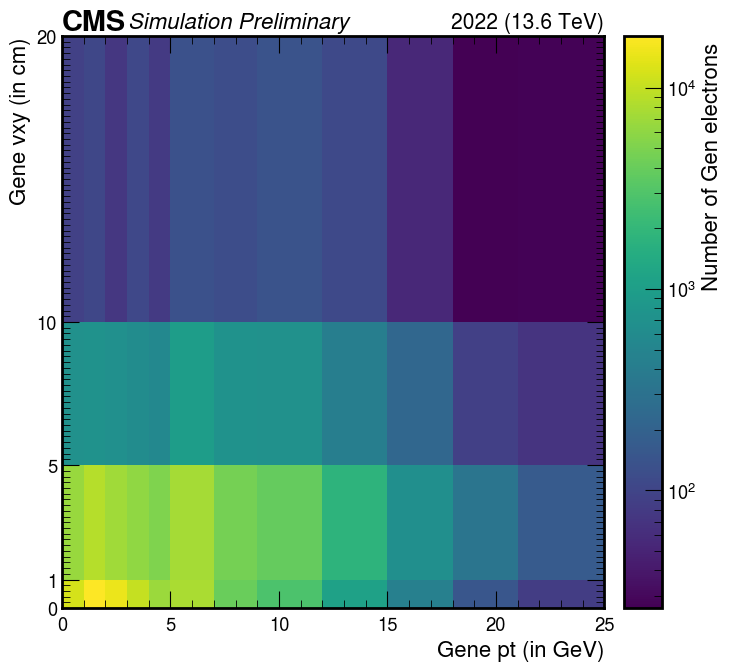

In [3]:
fig, ax = plt.subplots(figsize=(7,7))


# Plot settings
plot_dict = {
    'variable':'gen_ele_pt_vs_gen_ele_vxy1',
    'cut': 'cut1',
    'year': 2022
}


style_2d_dict = {
    'fig': fig,
    'ax': ax,
    'xrebin': None,
    'yrebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]  
    'ylim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': False, 
    'doLogx': False,
    'doLogz': True,
    'xlabel': "Gene pt (in GeV)",   # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': "Gene vxy (in cm)",   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'zlabel': 'Number of Gen electrons ',   
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'ptvslxy.png'
}


#signal points
m1 = 50
delta =0.1
ctau =10


count_den, edges_den0, edges_den1 = ptools.plot_signal_2D(sig_histo, m1, delta, ctau, plot_dict, style_2d_dict)
    
print (edges_den1)
print (len(edges_den1))
print ("count_den=", count_den)

pt_bins = 0.5*(edges_den0[1:] + edges_den0[:-1])

Saved: ./plots/signal_2018/ptvslxy.png
[ 0.  1.  2.  3.  4.  5.  7.  9. 12. 15. 18. 21. 25.]


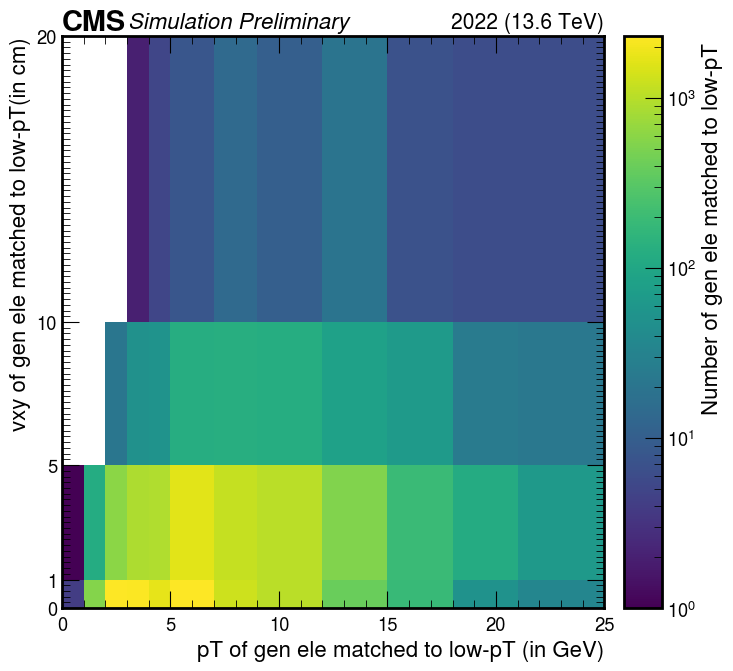

In [4]:
fig, ax = plt.subplots(figsize=(7,7))


# Plot settings
plot_dict = {
    'variable':'pT_genElePos_Lpt_Noxclean_vs_vxy_genElePos_Lpt_Noxclean',
    'cut': 'cut1',
    'year': 2022
}


style_2d_dict = {
    'fig': fig,
    'ax': ax,
    'xrebin': None,
    'yrebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]  
    'ylim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': False, 
    'doLogx': False,
    'doLogz': True,
    'xlabel': "pT of gen ele matched to low-pT (in GeV)",   # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': "vxy of gen ele matched to low-pT(in cm)",   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'zlabel': 'Number of gen ele matched to low-pT ',   
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'ptvslxy.png'
}


#signal points
m1 = 50
delta =0.1
ctau =10


count_num, edges_num0, edges_num1 = ptools.plot_signal_2D(sig_histo, m1, delta, ctau, plot_dict, style_2d_dict)
    
print (edges_num0)


In [5]:
def eff_determine_unc(n, d):
    eff = np.divide(n, d)
    unc = hist.intervals.ratio_uncertainty(n, d, 'efficiency')
    return eff, unc


efficiency_R, unc_eff_R = eff_determine_unc(count_num, count_den)

print (unc_eff_R)
print (unc_eff_R[:,:,0])

[[[0.00016135 0.00012737 0.         0.        ]
  [0.00127443 0.00123306 0.         0.        ]
  [0.00298273 0.00332316 0.00673902 0.        ]
  [0.00418229 0.00454954 0.01110743 0.01206393]
  [0.00534672 0.00547123 0.01253162 0.0267323 ]
  [0.00517589 0.00482823 0.01077414 0.0208568 ]
  [0.00736359 0.00651537 0.01429645 0.03028402]
  [0.00916421 0.00730821 0.01461328 0.02213473]
  [0.01487639 0.01109998 0.02003897 0.03763366]
  [0.02439744 0.0179444  0.03144281 0.04654374]
  [0.04072392 0.02702647 0.04950024 0.08746939]
  [0.05826399 0.03973677 0.05993849 0.0843892 ]]

 [[0.0002665  0.00035396 0.00267233 0.02002773]
  [0.00132765 0.00134998 0.00260797 0.01721817]
  [0.00303032 0.00344175 0.00829623 0.02490412]
  [0.00423804 0.00466849 0.01258649 0.02412112]
  [0.00541854 0.00559805 0.01408649 0.04006869]
  [0.0052288  0.00490557 0.01157917 0.02873858]
  [0.00745701 0.00662374 0.01522322 0.03762667]
  [0.00925908 0.00742866 0.01560371 0.02931308]
  [0.01514253 0.01132656 0.02160209 0.

In [6]:
eff_01=efficiency_R[:,0] #Lxy bin 0 values
unc_01 = unc_eff_R[:,:,0]

eff_15= efficiency_R[:,1] #Lxy bin 1 values
unc_15 = unc_eff_R[:,:,1]

eff_510=efficiency_R[:,2] #Lxy bin 2 values
unc_510 = unc_eff_R[:,:,2]

eff_1020 = efficiency_R[:,3] #Lxy bin 3 values
unc_1020 = unc_eff_R[:,:,3]


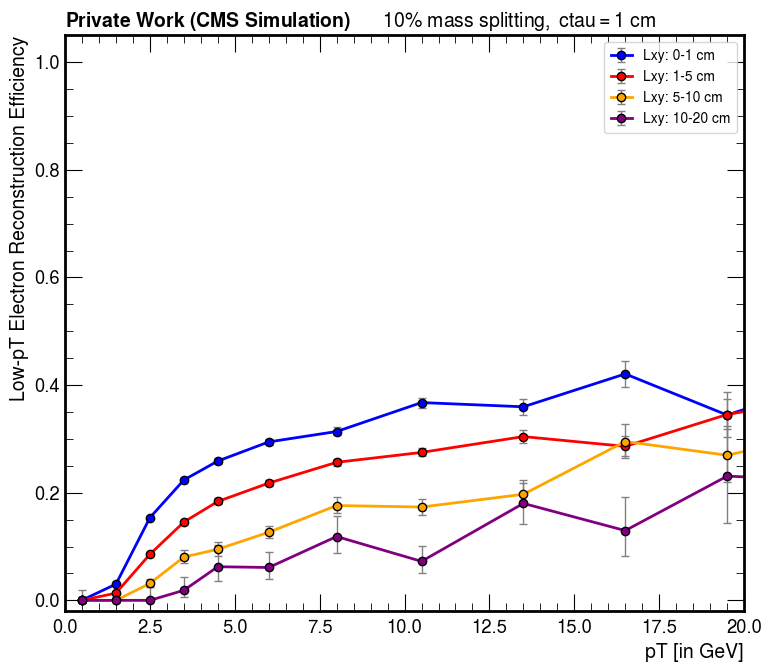

In [7]:
plt.figure(figsize=(8,7))

plt.errorbar(
    pt_bins,
    eff_01,
    yerr=unc_01,
    fmt='o-',
    linewidth=2,
    markersize=6,
    color='blue',
    markeredgecolor='black',
    ecolor='gray',
    elinewidth=1,
    capsize=3,
    label='Lxy: 0-1 cm'
)

plt.errorbar(
    pt_bins,
    eff_15,
    yerr=unc_15,
    fmt='o-',
    linewidth=2,
    markersize=6,
    color='red',
    markeredgecolor='black',
    ecolor='gray',
    elinewidth=1,
    capsize=3,
    label='Lxy: 1-5 cm'
)

plt.errorbar(
    pt_bins,
    eff_510,
    yerr=unc_510,
    fmt='o-',
    linewidth=2,
    markersize=6,
    color='orange',
    markeredgecolor='black',
    ecolor='gray',
    elinewidth=1,
    capsize=3,
    label='Lxy: 5-10 cm'
)

plt.errorbar(
    pt_bins,
    eff_1020,
    yerr=unc_1020,
    fmt='o-',
    linewidth=2,
    markersize=6,
    color='purple',
    markeredgecolor='black',
    ecolor='gray',
    elinewidth=1,
    capsize=3,
    label='Lxy: 10-20 cm'
)

# Axis styling
plt.ylim(-0.02, 1.05)
plt.xlim(0,20)
plt.xlabel(r"pT [in GeV]", fontsize=14)
plt.ylabel("Low-pT Electron Reconstruction Efficiency", fontsize=14)



# Grid helps readability
# plt.grid(True, linestyle='--', alpha=0.4)

# Better title formatting


# plt.title(
    
#     r"$10\%\ \mathrm{mass\ splitting},\ c\tau = 10\ \mathrm{mm}$",
#     fontsize=18
# )

plt.title(r"$\bf{Private\ Work\ (CMS\ Simulation)} \qquad \mathrm{10\% \ mass\ splitting,\ ctau = 1\ cm}$",
          fontsize=14, loc='left')

plt.legend(fontsize=10, frameon=True, loc='upper right')

plt.tight_layout()

plt.savefig("L_lxy_ERE.png", dpi=300)

Text(0.5, 1.0, '(m1,dm)=(50,5) GeV, Lpt matched')

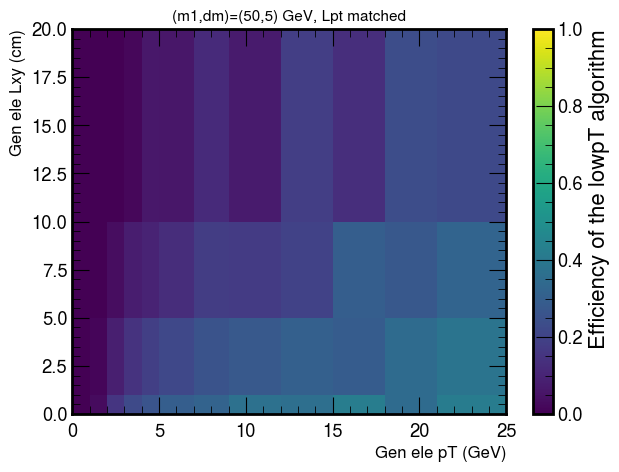

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.pcolormesh(edges_num0,edges_num1, efficiency_R.T, vmin=0, vmax=1)
plt.colorbar(label="Efficiency of the lowpT algorithm")

plt.xlabel("Gen ele pT (GeV)",fontsize=12)
plt.ylabel("Gen ele Lxy (cm)",fontsize=12)
plt.title("(m1,dm)=(50,5) GeV, Lpt matched", fontsize=11)